In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("SpotifyFeatures.csv")

print("Shape:", df.shape)
print("\nПерші рядки:")
display(df.head())

print("\nСтатистика числових колонок:")
display(df.describe())

Shape: (232725, 18)

Перші рядки:


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390



Статистика числових колонок:


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [3]:
features = [
    'popularity', 'acousticness', 'danceability', 'duration_ms',
    'energy', 'instrumentalness', 'liveness', 'loudness',
    'speechiness', 'tempo', 'valence'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

print("Стандартизовано ознак:", len(features))
print("Форма матриці:", X_scaled.shape)

Стандартизовано ознак: 11
Форма матриці: (232725, 11)


In [4]:
df_popular = df[df['popularity'] >= 85].copy()

print("Треків з popularity ≥ 85:", len(df_popular))
print("Розмірність після фільтрації:", df_popular.shape)
display(df_popular.head())

Треків з popularity ≥ 85: 417
Розмірність після фільтрації: (417, 18)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,0.0421,0.726,190440,0.554,0.000000,F,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335
9027,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319
9028,Dance,Halsey,Without Me,5p7ujcrUXASCNwRaWNHR1C,97,0.2970,0.752,201661,0.488,0.000009,F#,0.0936,-7.050,Major,0.0705,136.041,4/4,0.533
9029,Dance,Ariana Grande,needy,1TEL6MlSSVLSdhOSddidlJ,92,0.7800,0.647,171573,0.309,0.000007,G,0.2020,-7.948,Minor,0.0366,87.045,4/4,0.195
9030,Dance,Ariana Grande,NASA,4uTvPEr01pjTbZgl7jcKBD,91,0.4510,0.747,182000,0.458,0.000000,F#,0.2520,-6.891,Major,0.3030,75.029,4/4,0.470


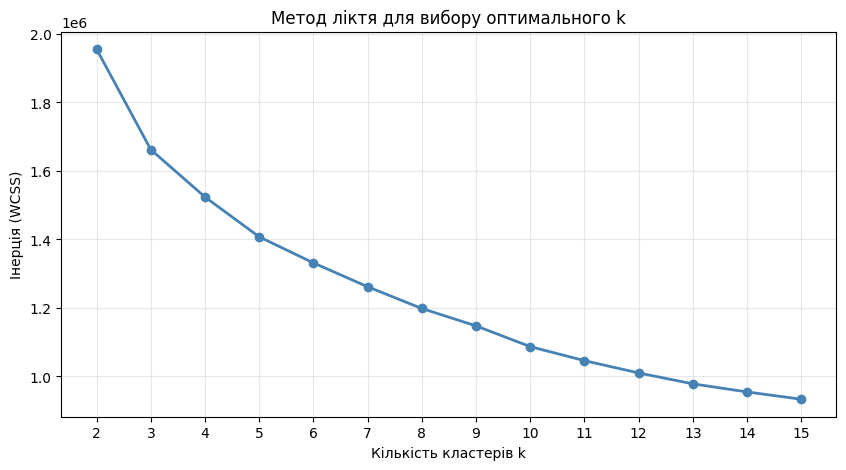

In [5]:
inertias = []
k_range = range(2, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', linewidth=2, color='steelblue')
plt.xlabel("Кількість кластерів k")
plt.ylabel("Інерція (WCSS)")
plt.title("Метод ліктя для вибору оптимального k")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
OPTIMAL_K = 6

print(f"Обране оптимальне значення k = {OPTIMAL_K}")
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Кількість треків у кожному кластері:\n")
print(df['cluster'].value_counts().sort_index())

Обране оптимальне значення k = 6
Кількість треків у кожному кластері:

cluster
0    46742
1    59661
2    57403
3    10060
4    32907
5    25952
Name: count, dtype: int64


In [8]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print("Пояснена дисперсія по компонентах:", pca.explained_variance_ratio_.round(3))
print(f"Загальна пояснена дисперсія: {pca.explained_variance_ratio_.sum():.1%}")

df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]
df['pca_3'] = X_pca[:, 2]

Пояснена дисперсія по компонентах: [0.328 0.155 0.106]
Загальна пояснена дисперсія: 59.0%


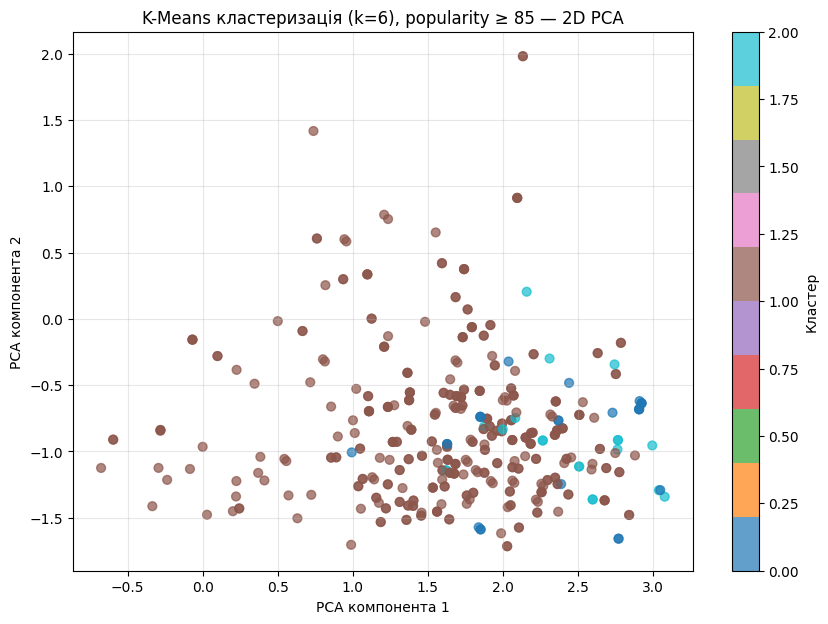

In [9]:
df_vis = df[df['popularity'] >= 85].copy()

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df_vis['pca_1'], df_vis['pca_2'],
    c=df_vis['cluster'], cmap='tab10',
    alpha=0.7, s=40
)
plt.colorbar(scatter, label='Кластер')
plt.xlabel("PCA компонента 1")
plt.ylabel("PCA компонента 2")
plt.title(f"K-Means кластеризація (k={OPTIMAL_K}), popularity ≥ 85 — 2D PCA")
plt.grid(True, alpha=0.3)
plt.show()

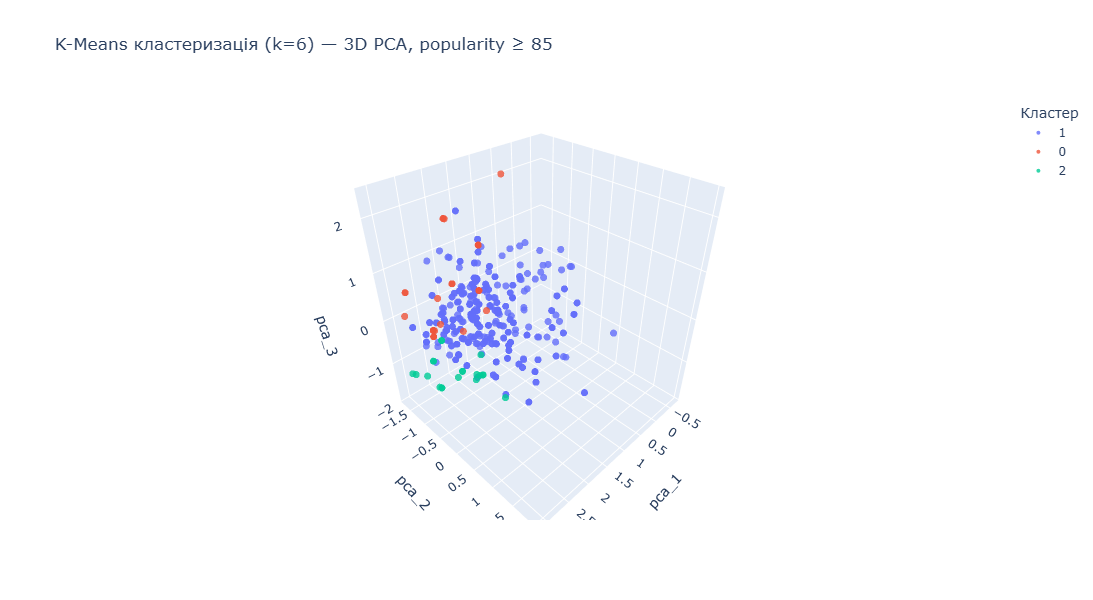

In [11]:
df_vis_sample = df_vis.sample(n=min(500, len(df_vis)), random_state=42)

fig = px.scatter_3d(
    df_vis_sample,
    x='pca_1', y='pca_2', z='pca_3',
    color=df_vis_sample['cluster'].astype(str),
    title=f"K-Means кластеризація (k={OPTIMAL_K}) — 3D PCA, popularity ≥ 85",
    labels={'color': 'Кластер'},
    opacity=0.8,
    width=800,
    height=600
)
fig.update_traces(marker=dict(size=4))
fig.show()

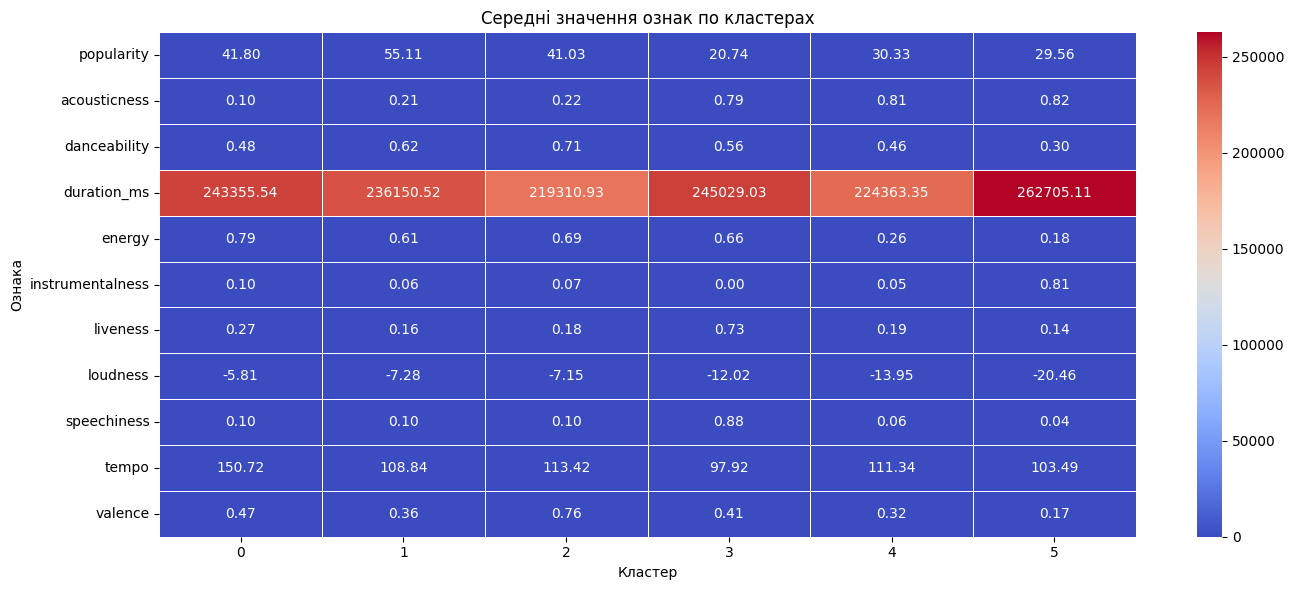

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
cluster,,,,,,,,,,,
0,41.805,0.104,0.481,243355.542,0.790,0.095,0.272,-5.806,0.098,150.721,0.473
1,55.110,0.207,0.622,236150.525,0.608,0.057,0.163,-7.283,0.099,108.843,0.358
2,41.032,0.219,0.711,219310.934,0.690,0.070,0.179,-7.146,0.098,113.421,0.756
3,20.740,0.794,0.563,245029.028,0.663,0.001,0.730,-12.018,0.880,97.916,0.414
4,30.334,0.809,0.457,224363.347,0.263,0.051,0.192,-13.953,0.060,111.336,0.320
5,29.563,0.825,0.304,262705.108,0.182,0.809,0.142,-20.459,0.045,103.492,0.166


In [12]:
cluster_stats = df.groupby('cluster')[features].mean().round(3)

plt.figure(figsize=(14, 6))
sns.heatmap(
    cluster_stats.T,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Середні значення ознак по кластерах")
plt.xlabel("Кластер")
plt.ylabel("Ознака")
plt.tight_layout()
plt.show()

display(cluster_stats)

In [13]:
print("Інтерпретація кластерів на основі середніх значень:\n")

for cluster_id in sorted(df['cluster'].unique()):
    row = cluster_stats.loc[cluster_id]
    print(f"Кластер {cluster_id}:")
    print(f"  danceability={row['danceability']:.2f}, energy={row['energy']:.2f}, "
          f"tempo={row['tempo']:.1f}, acousticness={row['acousticness']:.2f}, "
          f"instrumentalness={row['instrumentalness']:.2f}, "
          f"valence={row['valence']:.2f}")

    if row['energy'] > 0.7 and row['danceability'] > 0.65:
        label = "Енергійні танцювальні треки з високим темпом"
    elif row['acousticness'] > 0.5 and row['energy'] < 0.5:
        label = "Спокійні акустичні композиції"
    elif row['instrumentalness'] > 0.4:
        label = "Інструментальні / експериментальні треки"
    elif row['speechiness'] > 0.2:
        label = "Треки з вираженим вокалом або речитативом"
    elif row['valence'] > 0.7 and row['energy'] > 0.6:
        label = "Позитивні енергійні поп-треки"
    else:
        label = "Збалансовані треки середньої енергії"

    print(f"  → {label}\n")

Інтерпретація кластерів на основі середніх значень:

Кластер 0:
  danceability=0.48, energy=0.79, tempo=150.7, acousticness=0.10, instrumentalness=0.10, valence=0.47
  → Збалансовані треки середньої енергії

Кластер 1:
  danceability=0.62, energy=0.61, tempo=108.8, acousticness=0.21, instrumentalness=0.06, valence=0.36
  → Збалансовані треки середньої енергії

Кластер 2:
  danceability=0.71, energy=0.69, tempo=113.4, acousticness=0.22, instrumentalness=0.07, valence=0.76
  → Позитивні енергійні поп-треки

Кластер 3:
  danceability=0.56, energy=0.66, tempo=97.9, acousticness=0.79, instrumentalness=0.00, valence=0.41
  → Треки з вираженим вокалом або речитативом

Кластер 4:
  danceability=0.46, energy=0.26, tempo=111.3, acousticness=0.81, instrumentalness=0.05, valence=0.32
  → Спокійні акустичні композиції

Кластер 5:
  danceability=0.30, energy=0.18, tempo=103.5, acousticness=0.82, instrumentalness=0.81, valence=0.17
  → Спокійні акустичні композиції

